In [1]:
import numpy as np

def knn_from_scratch(X_train, y_train, X_test, k):
    predictions = []

    for x in X_test:
        # Step 1: Compute Euclidean distances
        distances = np.sqrt(np.sum((X_train - x) ** 2, axis=1))

        # Step 2: Get indices of k nearest neighbors
        k_indices = np.argsort(distances)[:k]

        # Step 3: Get labels of k nearest neighbors
        k_nearest_labels = y_train[k_indices]

        # Step 4: Majority vote
        values, counts = np.unique(k_nearest_labels, return_counts=True)
        prediction = values[np.argmax(counts)]

        predictions.append(prediction)

    return np.array(predictions)

### Create a small, basic dataset

In [6]:

import matplotlib.pyplot as plt

# Training data
X_train = np.array([
    [1, 1], [1.5, 1.5], [2, 2],
    [6, 6], [6.5, 7], [7, 6.5]
])
y_train = np.array([0, 0, 0, 1, 1, 1]) # Two classes: 0 and 1

# Test data
X_test = np.array([
    [1.2, 1.8], [6.8, 6.2],
    [3, 3], [5, 5]
])

k_value = 3 # Number of neighbors

### Apply the `knn_from_scratch` function

In [3]:
predictions = knn_from_scratch(X_train, y_train, X_test, k_value)

print(f"Training data:\n{X_train}")
print(f"Training labels:\n{y_train}")
print(f"\nTest data:\n{X_test}")
print(f"\nPredictions for test data (k={k_value}):\n{predictions}")

Training data:
[[1.  1. ]
 [1.5 1.5]
 [2.  2. ]
 [6.  6. ]
 [6.5 7. ]
 [7.  6.5]]
Training labels:
[0 0 0 1 1 1]

Test data:
[[1.2 1.8]
 [6.8 6.2]
 [3.  3. ]
 [5.  5. ]]

Predictions for test data (k=3):
[0 1 0 1]


### Plot the results

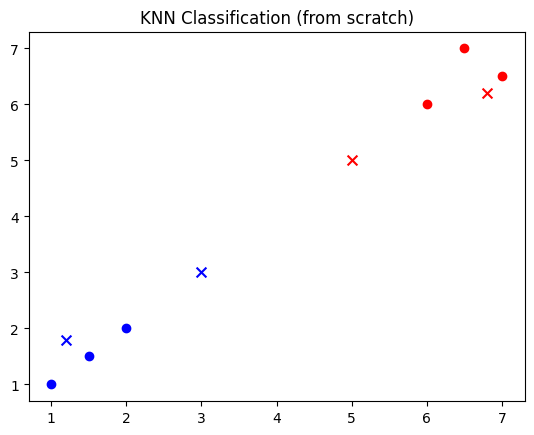

In [5]:
plt.figure()

# Plot training data
plt.scatter(X_train[y_train == 0, 0], X_train[y_train == 0, 1], c='blue', marker='o')
plt.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1], c='red', marker='o')

# Plot test data with predictions
plt.scatter(X_test[predictions == 0, 0], X_test[predictions == 0, 1], c='blue', marker='x', s=50)
plt.scatter(X_test[predictions == 1, 0], X_test[predictions == 1, 1], c='red', marker='x', s=50)

plt.title('KNN Classification (from scratch)')
plt.show()